In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install scikit-learn matplotlib seaborn

Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
# Install Kaggle
!pip install kaggle

# Upload your kaggle.json (API key) or use this method
from google.colab import files
files.upload()   # upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset (replace with the correct slug)
!kaggle datasets download -d amirberenji/thermal-images-of-induction-motor
!unzip thermal-images-of-induction-motor.zip -d /content/thermal_motor_data


Saving archive(4).zip to archive(4) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/amirberenji/thermal-images-of-induction-motor
License(s): Attribution 4.0 International (CC BY 4.0)
100% 6.67M/6.67M [00:00<00:00, 84.3MB/s]

Archive:  thermal-images-of-induction-motor.zip
  inflating: /content/thermal_motor_data/A&B50/291.bmp  
  inflating: /content/thermal_motor_data/A&B50/292.bmp  
  inflating: /content/thermal_motor_data/A&B50/293.bmp  
  inflating: /content/thermal_motor_data/A&B50/294.bmp  
  inflating: /content/thermal_motor_data/A&B50/295.bmp  
  inflating: /content/thermal_motor_data/A&B50/296.bmp  
  inflating: /content/thermal_motor_data/A&B50/297.bmp  
  inflating: /content/thermal_motor_data/A&B50/298.bmp  
  inflating: /content/thermal_motor_data/A&B50/299.bmp  
  inflating: /content/thermal_motor_data/A&B50/300.bmp  
  inflating: /cont

In [4]:
# Cell 1: Install libraries (if not already done)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install matplotlib seaborn scikit-learn

# Cell 2: Import libraries
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os

# Cell 3: Define transforms (preprocessing + augmentation)
# Thermal images benefit from these augmentations
transform = transforms.Compose([
    transforms.Resize((224, 224)),           # Standard size for pre-trained models
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # ImageNet normalization (works well)
])

# Cell 4: Load the dataset using ImageFolder
data_dir = '/content/thermal_motor_data'   # ← Change this to your actual folder path

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print("✅ Dataset loaded successfully!")
print(f"Total images: {len(full_dataset)}")
print(f"Classes ({len(full_dataset.classes)}):")
print(full_dataset.classes)

Looking in indexes: https://download.pytorch.org/whl/cu118
✅ Dataset loaded successfully!
Total images: 369
Classes (11):
['A&B50', 'A&C&B10', 'A&C&B30', 'A&C10', 'A&C30', 'A10', 'A30', 'A50', 'Fan', 'Noload', 'Rotor-0']


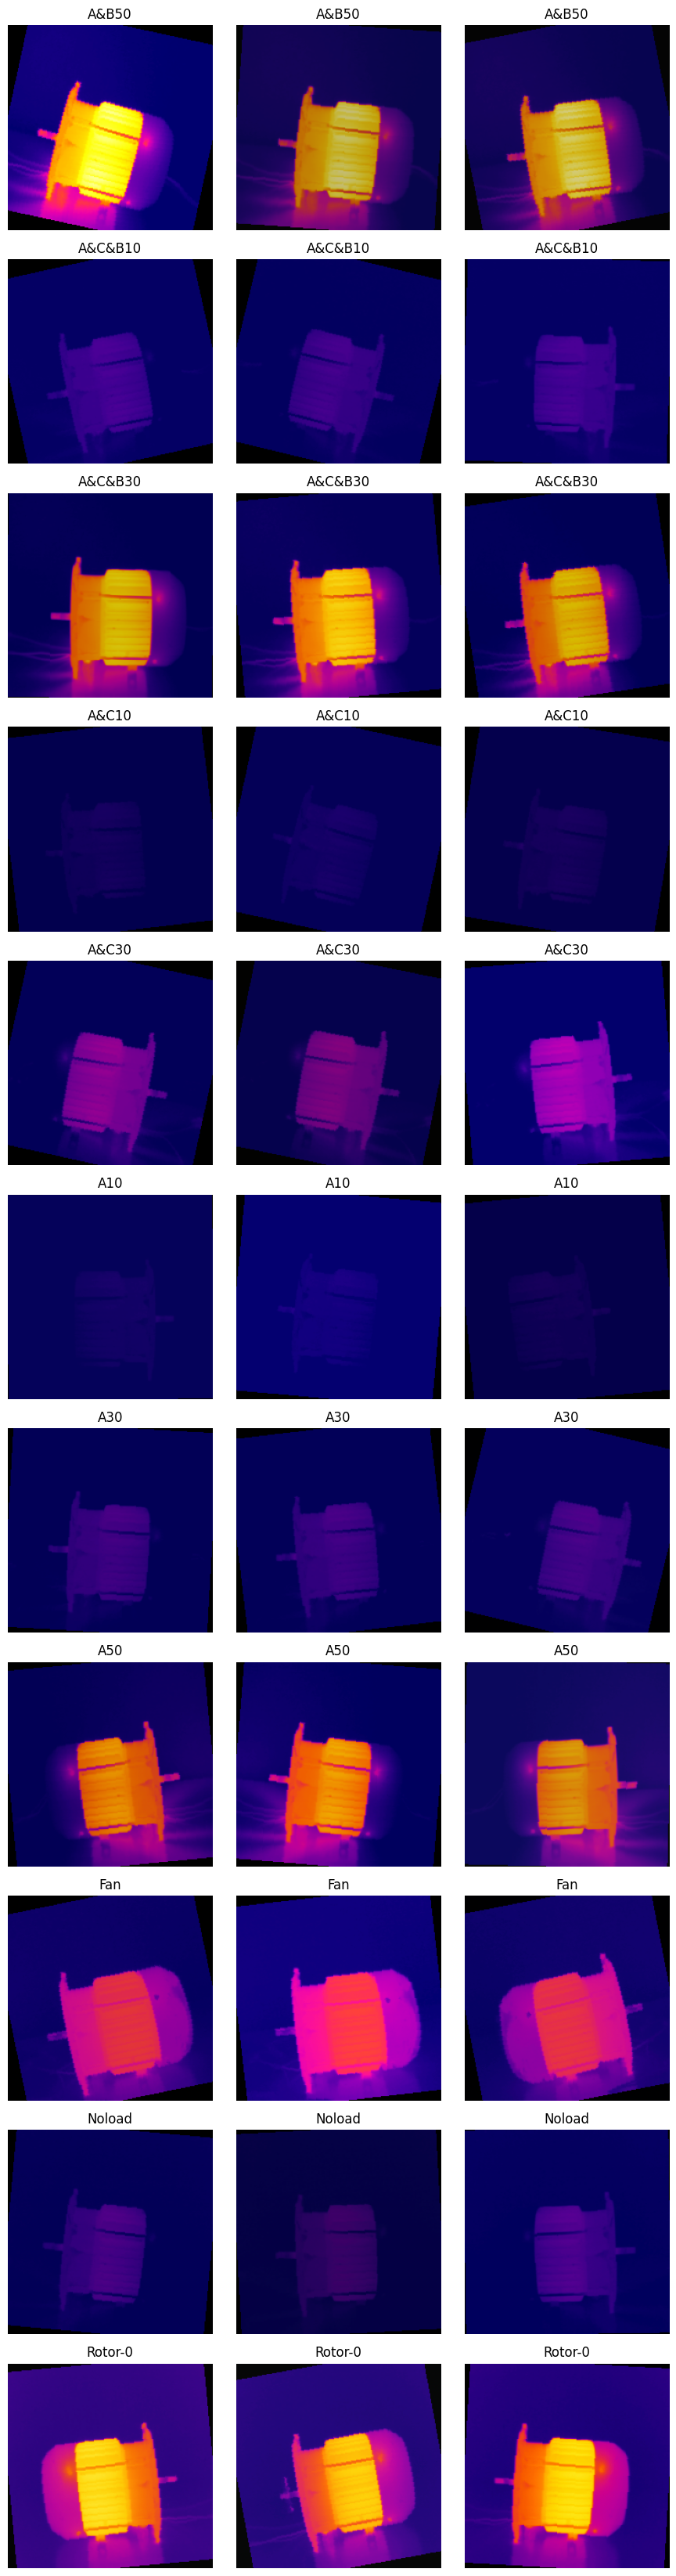

In [5]:
# Cell 5: Show sample images from each class
def show_samples(dataset, num_per_class=2):
    class_names = dataset.classes
    fig, axes = plt.subplots(len(class_names), num_per_class, figsize=(num_per_class*3, len(class_names)*3))

    for i, class_name in enumerate(class_names):
        # Get indices of this class
        indices = [idx for idx, label in enumerate(dataset.targets) if label == i]
        selected = np.random.choice(indices, num_per_class, replace=False)

        for j, idx in enumerate(selected):
            img, label = dataset[idx]
            img = img.permute(1, 2, 0).numpy()          # Convert tensor to numpy
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # denormalize
            img = np.clip(img, 0, 1)

            ax = axes[i, j] if len(class_names) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(class_name)
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(full_dataset, num_per_class=3)

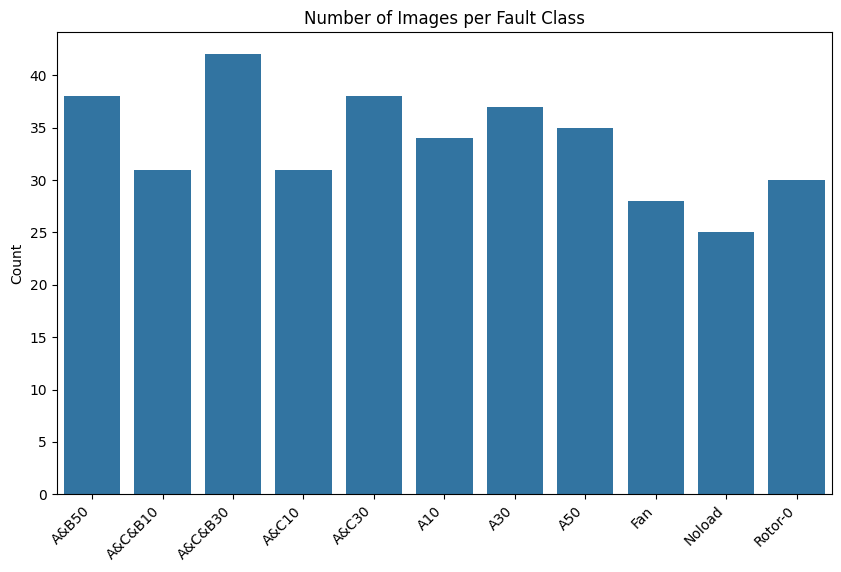

Class distribution:
A&B50: 38 images
A&C&B10: 31 images
A&C&B30: 42 images
A&C10: 31 images
A&C30: 38 images
A10: 34 images
A30: 37 images
A50: 35 images
Fan: 28 images
Noload: 25 images
Rotor-0: 30 images


In [6]:
# Cell 6: Class distribution
from collections import Counter

labels = [label for _, label in full_dataset.samples]
class_counts = Counter(labels)
class_names = full_dataset.classes

plt.figure(figsize=(10, 6))
sns.barplot(x=[class_names[i] for i in class_counts.keys()],
            y=list(class_counts.values()))
plt.xticks(rotation=45, ha='right')
plt.title("Number of Images per Fault Class")
plt.ylabel("Count")
plt.show()

print("Class distribution:")
for i, count in class_counts.items():
    print(f"{class_names[i]}: {count} images")

In [7]:
from torch.utils.data import random_split

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Train samples: 295
Validation samples: 74


In [8]:
# Cell 7: Import additional libraries
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Cell 8: Split dataset into Train and Validation (if not done in Step 4)
# We use 80% for training, 20% for validation

dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

Training images: 295
Validation images: 74
Number of classes: 11


In [9]:
# Cell 9: Define separate transforms for train and validation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Re-load datasets with correct transforms
train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

# Re-split (apply the new transforms)
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ DataLoaders ready!")

✅ DataLoaders ready!


In [10]:
# Cell 10: Load pre-trained model + modify for your number of classes
model = models.resnet18(pretrained=True)   # Change to models.mobilenet_v2(pretrained=True) if you prefer

# Replace the final fully connected layer
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"✅ Model loaded: ResNet18 with {num_classes} output classes")
print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


✅ Model loaded: ResNet18 with 11 output classes
Using device: cuda


In [11]:
# Cell 11: Quick forward pass test
model.eval()
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)
outputs = model(sample_images)
print(f"Output shape (batch, classes): {outputs.shape}")

Output shape (batch, classes): torch.Size([32, 11])


In [12]:
# Cell 12: Define loss function, optimizer, and scheduler
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()   # Good default for classification

# Use a smaller learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Scheduler: reduce LR when validation accuracy stops improving
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

print("✅ Loss, optimizer, and scheduler ready!")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [13]:
# Cell 12: Corrected version (remove 'verbose')
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Fixed scheduler - no 'verbose' argument
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print("✅ Loss, optimizer, and scheduler ready!")

✅ Loss, optimizer, and scheduler ready!


In [14]:
# Cell 13: Training Loop (Corrected + Improved)

num_epochs = 15
best_val_acc = 0.0
patience = 5
counter = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # === TRAINING ===
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)

    # === VALIDATION ===
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Scheduler step + manual LR print when it changes
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    if new_lr < old_lr:
        print(f"Learning rate reduced to {new_lr:.6f}")

    print("-" * 70)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_thermal_motor_model.pth')
        print(f"✅ New best model saved! Val Acc: {val_acc:.2f}%")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

print(f"\n🎉 Training completed! Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/15]
Train Loss: 1.4868 | Train Acc: 41.36%
Val Loss:   2.0566 | Val Acc:   43.24%
----------------------------------------------------------------------
✅ New best model saved! Val Acc: 43.24%
Epoch [2/15]
Train Loss: 0.7212 | Train Acc: 68.47%
Val Loss:   9.6000 | Val Acc:   32.43%
----------------------------------------------------------------------
Epoch [3/15]
Train Loss: 0.5997 | Train Acc: 74.92%
Val Loss:   0.5747 | Val Acc:   75.68%
----------------------------------------------------------------------
✅ New best model saved! Val Acc: 75.68%
Epoch [4/15]
Train Loss: 0.5882 | Train Acc: 79.32%
Val Loss:   1.1805 | Val Acc:   55.41%
----------------------------------------------------------------------
Epoch [5/15]
Train Loss: 0.5491 | Train Acc: 72.88%
Val Loss:   0.9471 | Val Acc:   74.32%
----------------------------------------------------------------------
Epoch [6/15]
Train Loss: 0.3328 | Train Acc: 86.44%
Val Loss:   1.7580 | Val Acc:   55.41%
-------------------

In [15]:
# Cell 15: Load the best saved model
import torch
import torchvision.models as models
import torch.nn as nn
from PIL import Image

# Re-create the model architecture (same as before)
model = models.resnet18(pretrained=False)   # pretrained=False because we load our own weights
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load the best weights
model.load_state_dict(torch.load('best_thermal_motor_model.pth', map_location=device))
model = model.to(device)
model.eval()   # Set to evaluation mode

print("✅ Best model loaded successfully!")
print(f"Ready for inference on {num_classes} classes: {full_dataset.classes}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Best model loaded successfully!
Ready for inference on 11 classes: ['A&B50', 'A&C&B10', 'A&C&B30', 'A&C10', 'A&C30', 'A10', 'A30', 'A50', 'Fan', 'Noload', 'Rotor-0']


In [17]:
# Cell 16: Inference function for new thermal images

def predict_thermal_fault(image_path, model, transform, class_names, device):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)   # Add batch dimension

    # Predict
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        predicted_idx = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_idx].item() * 100

    predicted_class = class_names[predicted_idx]

    print(f"Image: {image_path}")
    print(f"Predicted Fault: **{predicted_class}**")
    print(f"Confidence: {confidence:.2f}%")

    # Show top 3 predictions
    top3_prob, top3_idx = torch.topk(probabilities, 3)
    print("\nTop 3 predictions:")
    for i in range(3):
        print(f"{class_names[top3_idx[i]]}: {top3_prob[i].item()*100:.2f}%")

    return predicted_class, confidence

# Define the same validation transform for consistent inference
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
# Get one sample from validation set
val_iter = iter(val_loader)
images, labels = next(val_iter)
test_image = images[0]   # first image in batch
true_label = full_dataset.classes[labels[0].item()]

# Save it temporarily to disk for testing the function
import torchvision.utils as vutils
vutils.save_image(test_image, 'test_sample.jpg')

# Run prediction
predict_thermal_fault('test_sample.jpg', model, inference_transform, full_dataset.classes, device)
print(f"\nTrue label was: {true_label}")

Image: test_sample.jpg
Predicted Fault: **A10**
Confidence: 79.33%

Top 3 predictions:
A10: 79.33%
A&C10: 11.57%
A&C&B30: 5.22%

True label was: A&C10


In [19]:
# Example - replace with your actual file paths
image_paths = [
    '/content/new_motor_healthy.jpg',
    '/content/new_motor_overheat.jpg',
    '/content/new_motor_fan_failure.jpg'
]

for path in image_paths:
    predict_thermal_fault(path, model, inference_transform, full_dataset.classes, device)
    print("-" * 50)

FileNotFoundError: [Errno 2] No such file or directory: '/content/new_motor_healthy.jpg'

In [20]:
# Cell 17: Save a few real images from validation set for testing
import torchvision.utils as vutils
import os

os.makedirs('/content/test_images', exist_ok=True)

# Take 5 images from validation loader
val_iter = iter(val_loader)
images, labels = next(val_iter)   # get one batch

for i in range(min(5, len(images))):
    img_tensor = images[i]
    true_label_idx = labels[i].item()
    true_class = full_dataset.classes[true_label_idx]

    # Save image
    filename = f'/content/test_images/sample_{i}_{true_class}.jpg'
    vutils.save_image(img_tensor, filename)
    print(f"Saved: {filename} → True label: {true_class}")

Saved: /content/test_images/sample_0_A&C10.jpg → True label: A&C10
Saved: /content/test_images/sample_1_Fan.jpg → True label: Fan
Saved: /content/test_images/sample_2_Fan.jpg → True label: Fan
Saved: /content/test_images/sample_3_A30.jpg → True label: A30
Saved: /content/test_images/sample_4_Noload.jpg → True label: Noload


In [21]:
# Cell 18: Updated inference function (same as before, but we'll use it now)
def predict_thermal_fault(image_path, model, transform, class_names, device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        predicted_idx = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_idx].item() * 100

    predicted_class = class_names[predicted_idx]

    print(f"\n📸 Image: {os.path.basename(image_path)}")
    print(f"🔮 Predicted Fault: **{predicted_class}**")
    print(f"✅ Confidence: {confidence:.2f}%")

    # Top 3
    top3_prob, top3_idx = torch.topk(probabilities, 3)
    print("Top 3:")
    for j in range(3):
        print(f"   {class_names[top3_idx[j]]}: {top3_prob[j].item()*100:.2f}%")

    return predicted_class, confidence

In [22]:
# Cell 19: Test on the saved validation images
test_folder = '/content/test_images'
test_images = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith('.jpg')]

for path in test_images[:5]:   # test first 5
    predict_thermal_fault(path, model, inference_transform, full_dataset.classes, device)
    print("-" * 60)


📸 Image: sample_0_A&C10.jpg
🔮 Predicted Fault: **A10**
✅ Confidence: 46.99%
Top 3:
   A10: 46.99%
   A&C&B30: 22.60%
   A&C10: 11.90%
------------------------------------------------------------

📸 Image: sample_2_Fan.jpg
🔮 Predicted Fault: **Fan**
✅ Confidence: 65.86%
Top 3:
   Fan: 65.86%
   A&C30: 10.35%
   A10: 7.24%
------------------------------------------------------------

📸 Image: sample_1_Fan.jpg
🔮 Predicted Fault: **Fan**
✅ Confidence: 81.00%
Top 3:
   Fan: 81.00%
   A&C30: 17.17%
   A30: 0.97%
------------------------------------------------------------

📸 Image: sample_3_A30.jpg
🔮 Predicted Fault: **A&C&B30**
✅ Confidence: 32.20%
Top 3:
   A&C&B30: 32.20%
   A10: 29.30%
   A30: 18.18%
------------------------------------------------------------

📸 Image: sample_4_Noload.jpg
🔮 Predicted Fault: **A10**
✅ Confidence: 81.66%
Top 3:
   A10: 81.66%
   A&C10: 11.48%
   A&C&B30: 3.71%
------------------------------------------------------------


In [23]:
# Cell 20: Install Gradio
!pip install gradio -q

In [24]:
# Cell 21: Create the Gradio Interface

import gradio as gr
from PIL import Image
import torch
import torchvision.transforms as transforms

# Reuse the same inference transform
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Class names from your dataset
class_names = full_dataset.classes

# Load best model again (just in case)
model = models.resnet18(pretrained=False)
num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load('best_thermal_motor_model.pth', map_location=device))
model = model.to(device)
model.eval()

def predict_image(image):
    if image is None:
        return "Please upload an image", "No prediction", ""

    # Preprocess
    input_tensor = inference_transform(image).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        predicted_idx = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_idx].item() * 100

    predicted_class = class_names[predicted_idx]

    # Create smart maintenance alert based on prediction
    if predicted_class.lower() == "healthy" or predicted_class.lower() == "normal":
        alert = "✅ NORMAL OPERATION\nNo immediate action needed. Continue regular monitoring."
        color = "green"
    else:
        alert = f"⚠️ ALERT: {predicted_class.upper()} DETECTED\n" \
                f"Recommendation: Schedule maintenance soon. Check motor windings/bearings/fan.\n" \
                f"Risk: Potential overheating → downtime if ignored."
        color = "red"

    result_text = f"**Predicted Fault:** {predicted_class}\n**Confidence:** {confidence:.2f}%"

    return result_text, alert, f"Severity: {'High' if confidence > 85 else 'Medium'}"

# Gradio Interface
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Thermal Image of Motor / Bearing / Panel"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Textbox(label="Maintenance Alert"),
        gr.Textbox(label="Severity")
    ],
    title="🔥 Smart Thermal Vision System for Predictive Maintenance",
    description="Upload an infrared/thermal image → AI detects overheating faults early.\n"
                "Supports motors, bearings, electrical panels. Prototype for manufacturing, ships & aircraft.",
    examples=None,   # You can add example images later
    allow_flagging="never"
)

print("✅ Gradio interface ready! Launching...")
iface.launch(share=True, debug=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


✅ Gradio interface ready! Launching...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://096dc65c7737335976.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
